# Reconstruction: fine-tuned with a frozen head variants against the baseline (axis-100-3000)

Where along m/z and on which held-out image does a variant reconstruct better or worse than the baseline, and how do the spectra of the best variant differ from those of the baseline? Stage shown: **fine-tuned with a frozen head**, i.e. the pretrained model after 10 epochs on the real training data with the head frozen to the synthetic head (verified bitwise); encoder and decoder adapt.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_reconstruction"
AXIS = "axis-100-3000"
STAGE = "frozen_head"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]
EVALUATIONS = ['test', 'test_combined', 'heldout_image', 'heldout_image_per_image']

windows = table('window_improvement_summary')
edges = table('window_improvements')[['window', 'window_lower', 'window_upper']].drop_duplicates()
BEST = metadata['best_variant']
print('Best variant:', BEST, '| baseline representative:', metadata['baseline_representative'])

Analysis: stage_reconstruction | axis: axis-100-3000 | stage: frozen_head | models: 55
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Best variant: P1_permutation | baseline representative: metaspace-pretrain-repaired-20260923-01__grid_0011__rep_01__real_only


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_reconstruction` reads the per-pixel window arrays of every model from the `inference` level
(contribution of each 100 Da window to $W_1$, within-window $W_1$, input and output mass per window), the
per-bin error aggregates of the representatives and the fixed spectrum cases.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_reconstruction > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute window costs of every variant and of the real-only baseline

### Methodology

#### Theoretical

The improvement plots below show paired differences; here the absolute window costs are drawn for the baseline
and every variant together, so that one sees at which level and in which m/z range a variant differs from the
baseline: the within-window $W_1$ (shape of the spectrum inside a 100 Da window) and the contribution of the
window to the global $W_1$.

#### Implementation

`window_summary` (one value per model, population and window) and `image_breakdown` (held-out W1 per image; the baseline value of the same repetition is `reference_value`).

#### Figure descriptions

        Two figures (within-window W1, window contribution): one panel per population (test, held-out); x = window
        centre; black line with band = real-only baseline (mean, range over repetitions); coloured lines = variant
        means. Table: held-out within-window W1 per window. Last figure: held-out W1 per image, one panel per image.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

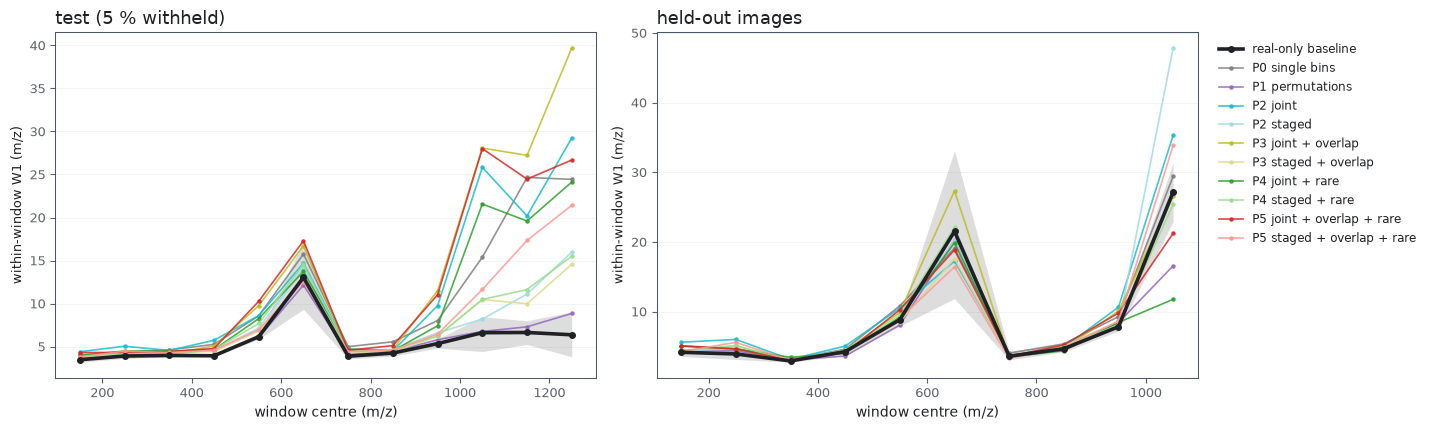

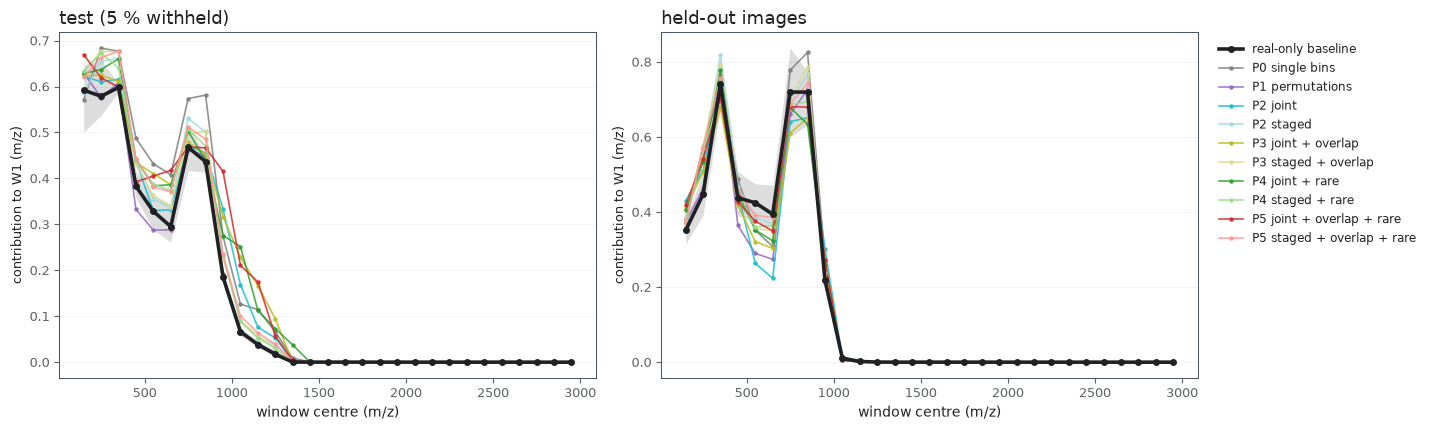

Held-out within-window W1 per window


window_label,100-200,200-300,300-400,400-500,500-600,600-700,700-800,800-900,900-1000,1000-1100,1100-1200,1200-1300,1300-1400,1400-1500,1500-1600,1600-1700,1700-1800,1800-1900,1900-2000,2000-2100,2100-2200,2200-2300,2300-2400,2400-2500,2500-2600,2600-2700,2700-2800,2800-2900,2900-3000
variant,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
baseline,4.164 +/- 0.372,3.923 +/- 0.631,2.925 +/- 0.105,4.261 +/- 0.400,8.843 +/- 0.673,21.515 +/- 9.058,3.598 +/- 0.468,4.673 +/- 0.436,7.827 +/- 0.509,27.161 +/- 5.975,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P0_single,4.480 +/- 0.459,4.680 +/- 1.107,3.144 +/- 0.514,4.614 +/- 0.537,10.832 +/- 3.376,19.111 +/- 5.092,4.043 +/- 0.666,5.368 +/- 1.231,9.276 +/- 2.380,29.405 +/- 22.372,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P1_permutation,4.388 +/- 0.189,4.367 +/- 1.515,3.077 +/- 0.385,3.617 +/- 0.254,8.080 +/- 0.557,20.240 +/- 8.918,3.425 +/- 0.207,4.929 +/- 0.301,8.420 +/- 0.963,16.569 +/- 11.249,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P2_joint_base,5.612 +/- 1.613,6.005 +/- 3.085,3.147 +/- 0.313,5.059 +/- 1.527,10.492 +/- 2.498,17.261 +/- 4.555,3.681 +/- 0.150,4.870 +/- 0.310,10.635 +/- 1.191,35.307 +/- 27.403,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P2_staged_base,4.380 +/- 0.409,4.659 +/- 0.878,3.130 +/- 0.227,4.435 +/- 0.624,9.106 +/- 1.580,20.303 +/- 7.215,3.488 +/- 0.361,5.098 +/- 0.309,8.010 +/- 1.154,47.834 +/- 30.664,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P3_joint_overlap,5.110 +/- 0.300,4.716 +/- 0.690,2.818 +/- 0.340,4.432 +/- 0.571,9.874 +/- 0.900,27.329 +/- 13.283,3.477 +/- 0.220,4.634 +/- 0.403,10.097 +/- 1.849,26.540 +/- 23.260,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P3_staged_overlap,4.380 +/- 0.301,5.031 +/- 0.705,3.212 +/- 0.476,4.078 +/- 0.362,8.571 +/- 0.702,17.614 +/- 1.864,3.545 +/- 0.206,5.024 +/- 0.255,8.620 +/- 0.726,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P4_joint_rare,5.058 +/- 0.948,4.650 +/- 0.701,3.442 +/- 0.541,4.035 +/- 0.344,9.225 +/- 0.560,19.873 +/- 5.725,3.508 +/- 0.085,4.383 +/- 0.300,8.450 +/- 1.209,11.764 +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -
P4_staged_rare,4.361 +/- 0.189,5.157 +/- 0.529,2.885 +/- 0.201,4.489 +/- 0.729,9.502 +/- 1.098,22.086 +/- 6.057,3.490 +/- 0.328,5.101 +/- 0.364,8.067 +/- 0.926,25.383 +/- 13.958,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -,nan +/- -


In [4]:
window_abs = table('window_summary')
for metric, label in (('within', 'within-window W1 (m/z)'), ('contribution', 'contribution to W1 (m/z)')):
    figures.window_values(window_abs[window_abs.metric == metric], populations=['test', 'heldout_image'],
                          variants=VARIANTS, labels=LABELS_ABS, colors=VARIANT_COLORS, baseline=BASELINE,
                          ylabel=label, theme=theme)
    plt.show()
held = window_abs[(window_abs.metric == 'within') & (window_abs.population == 'heldout_image')]
window_order = list(held.drop_duplicates('window_label').sort_values('window_lower').window_label)
print('Held-out within-window W1 per window')
display(figures.comparison_table(held, index='variant', columns='window_label', baseline=BASELINE, order=ABS_ORDER,
                                 column_order=window_order, direction={label: 'lower' for label in window_order}))

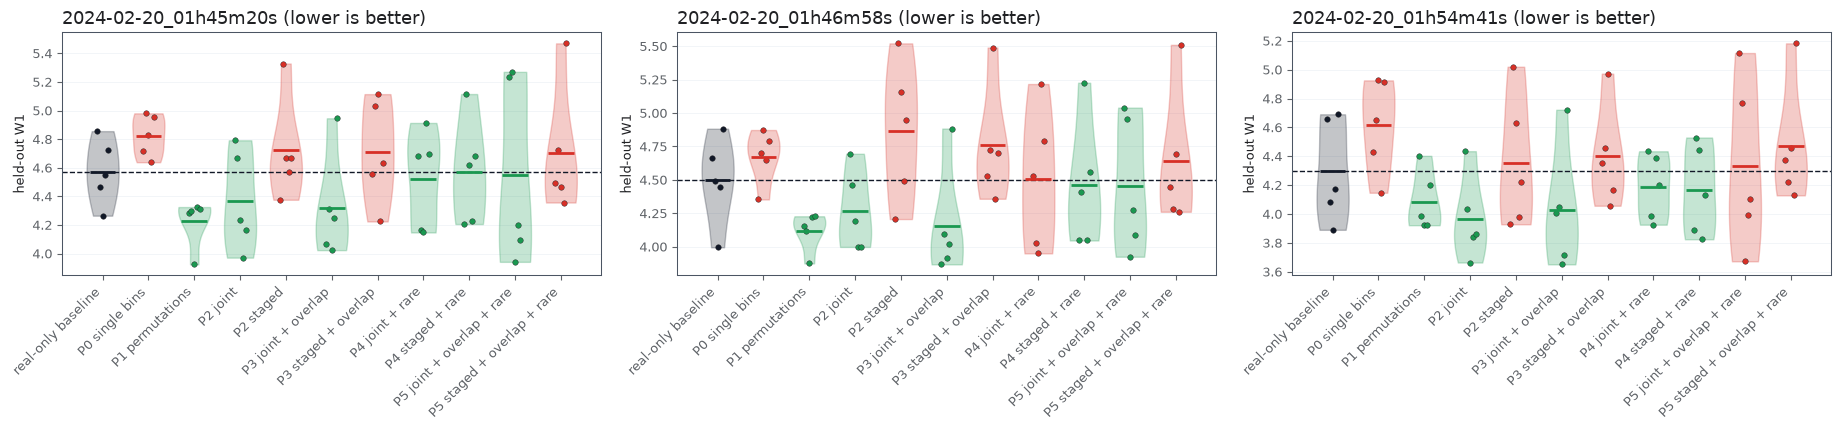

In [5]:
image_abs = table('image_breakdown')
w1 = image_abs[image_abs.metric == 'masserstein']
w1 = pd.concat([w1.drop_duplicates(['repetition', 'dataset_id']).assign(variant=BASELINE, value=lambda frame: frame.reference_value), w1])
datasets = sorted(w1.dataset_id.unique())
figure, axes = plt.subplots(1, len(datasets), figsize=(6.2 * len(datasets), 4.4), dpi=theme.figure_dpi)
for ax, dataset in zip(np.atleast_1d(axes), datasets):
    figures.value_violins(w1[w1.dataset_id == dataset], value='value', group='variant', order=ABS_ORDER, labels=LABELS_ABS,
                          baseline=BASELINE, direction='lower', ylabel='held-out W1', title=dataset, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

- Held-out within-window W1 per window: the baseline is beaten in 31 of 99 variant x window cells; best variant by cells: P1 permutations (5 of 10 windows).
- held-out W1 of image 2024-02-20_01h45m20s: baseline 4.572; others 4.228-4.824; 6 of 10 better than the baseline; best P1 permutations (4.228), worst P0 single bins (4.824).
- held-out W1 of image 2024-02-20_01h46m58s: baseline 4.496; others 4.119-4.866; 5 of 10 better than the baseline; best P1 permutations (4.119), worst P2 staged (4.866).
- held-out W1 of image 2024-02-20_01h54m41s: baseline 4.301; others 3.967-4.614; 5 of 10 better than the baseline; best P2 joint (3.967), worst P0 single bins (4.614).

### Notes

## Window-level improvement along m/z

### Methodology

#### Theoretical

$W_1$ of a spectrum decomposes into window contributions $c_W$ (the transport cost paid inside window $W$;
$\sum_W c_W = W_1$). The within-window $W_1$ compares the renormalized spectra inside $W$ (shape only).
The improvement of either quantity shows *where* on the axis a variant gains or loses.

#### Implementation

`window_improvement_summary`: per variant, population, window and quantity the summary over repetitions of
the paired improvement of the population mean.

#### Figure descriptions

Four panels (rows: contribution, within-window $W_1$; columns: test, held-out images); x = window centre,
line = mean improvement per variant, band = 95 % interval, dashed line = baseline. The pretrained stage uses a
symmetric-log y axis because the losses are orders of magnitude larger. Table: mean [interval] of the test
contribution per window.

window_label,100-200,200-300,300-400,400-500,500-600,600-700,700-800,800-900,900-1000,1000-1100,1100-1200,1200-1300,1300-1400,1400-1500,1500-1600,1600-1700,1700-1800,1800-1900,1900-2000,2000-2100,2100-2200,2200-2300,2300-2400,2400-2500,2500-2600,2600-2700,2700-2800,2800-2900,2900-3000
variant,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
P0_single,+0.021,-0.105,-0.079,-0.104,-0.104,-0.113,-0.106,-0.145,-0.089,-0.060,-0.076,-0.049,-0.009,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
P1_permutation,-0.037,+0.003,-0.010,+0.050,+0.041,+0.007,+0.005,-0.013,-0.006,+0.002,-0.003,-0.005,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
P2_joint_base,-0.030,-0.031,-0.018,-0.055,-0.002,-0.036,-0.002,-0.020,-0.148,-0.103,-0.038,-0.036,-0.002,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
P2_staged_base,+0.007,-0.075,-0.064,-0.057,-0.027,-0.041,-0.063,-0.064,-0.046,-0.024,-0.014,-0.022,-0.001,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
P3_joint_overlap,-0.032,-0.045,-0.013,-0.052,-0.082,-0.091,-0.011,-0.016,-0.131,-0.162,-0.128,-0.078,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
P3_staged_overlap,-0.040,-0.098,-0.077,-0.047,-0.035,-0.044,-0.028,-0.067,-0.044,-0.022,-0.021,-0.014,-0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
P4_joint_rare,-0.036,-0.058,-0.062,-0.058,-0.056,-0.091,-0.035,-0.003,-0.090,-0.185,-0.074,-0.056,-0.037,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
P4_staged_rare,-0.041,-0.094,-0.043,-0.058,-0.059,-0.079,-0.040,-0.034,-0.048,-0.023,-0.014,-0.013,-0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
P5_joint_all,-0.077,-0.040,-0.001,-0.009,-0.077,-0.122,-0.001,-0.030,-0.230,-0.144,-0.136,-0.040,-0.004,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000


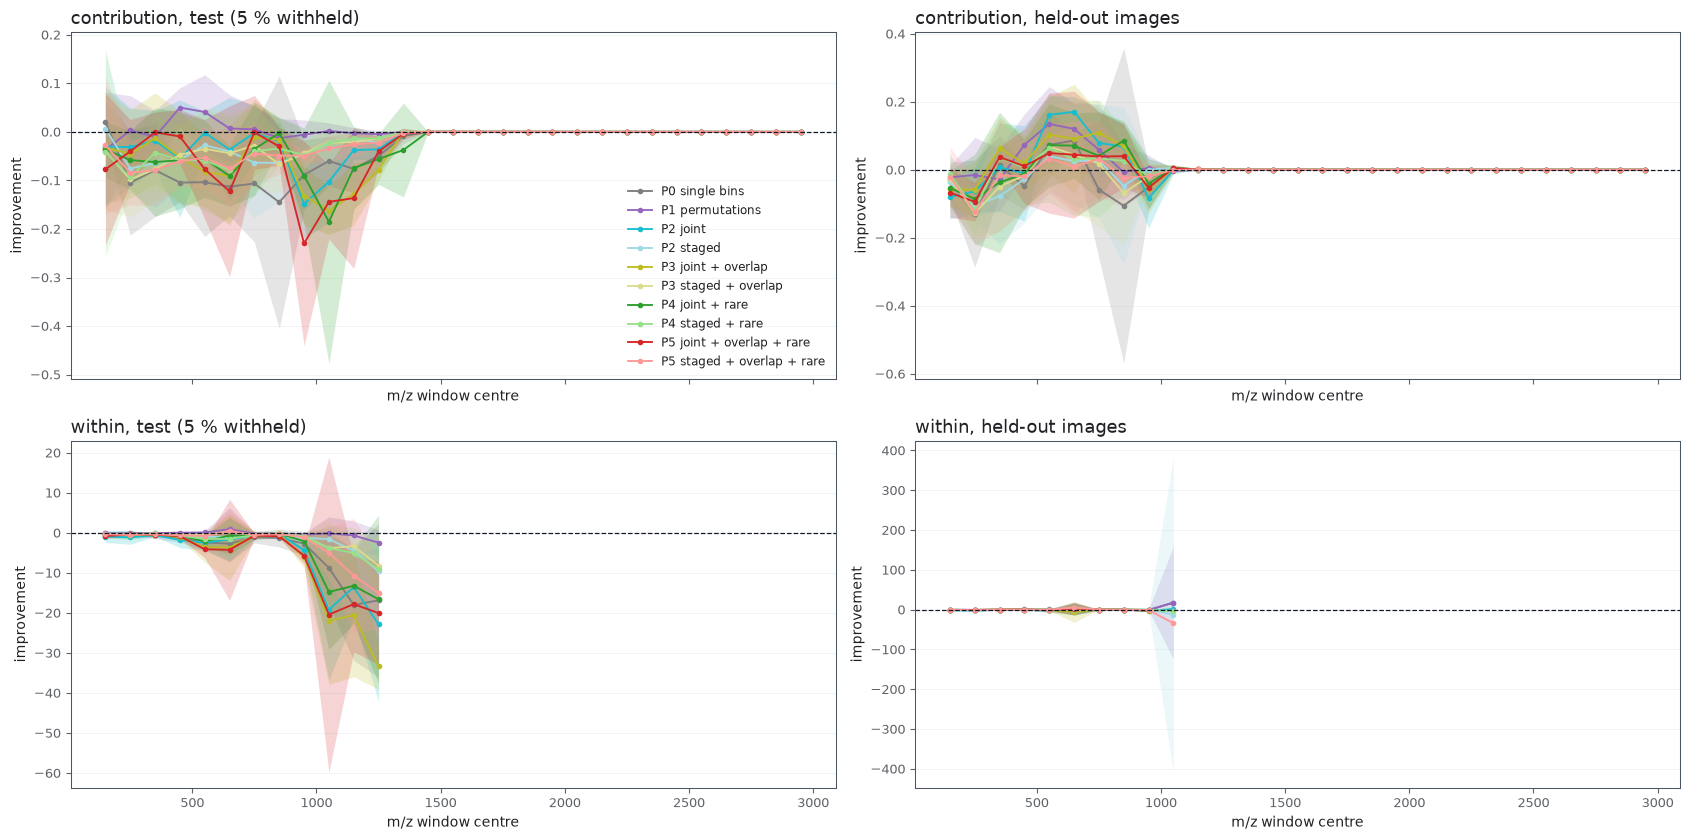

In [6]:
profile = windows.merge(edges, on='window')
profile['centre'] = (profile.window_lower + profile.window_upper) / 2
figure, axes = plt.subplots(2, 2, figsize=(17, 8.5), dpi=theme.figure_dpi, sharex=True)
for row, metric in enumerate(['contribution', 'within']):
    for column, population in enumerate(['test', 'heldout_image']):
        rows = profile[(profile.metric == metric) & (profile.population == population)]
        figures.epoch_curves(rows, levels=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, x='centre', low='ci_low',
                             high='ci_high', reference=0.0, xlabel='m/z window centre', ylabel='improvement',
                             title=f'{metric}, {EVALUATION_NAMES[population]}', ax=axes[row, column], theme=theme)
        if STAGE == 'pretrained':
            axes[row, column].set_yscale('symlog', linthresh=1e-2)
for ax in axes.flat[1:]:
    ax.get_legend().remove()
figure.tight_layout()
test = windows[(windows.metric == 'contribution') & (windows.population == 'test')]
## Mean improvement per window (green = better than the baseline, red = worse)
window_order = list(test.drop_duplicates('window_label').sort_values('window').window_label)
matrix = test.pivot_table(index='variant', columns='window_label', values='mean').reindex(VARIANTS)[window_order]
limit = float(np.nanmax(np.abs(matrix.to_numpy())))
display(matrix.style.format('{:+.3f}').background_gradient(cmap='RdYlGn', vmin=-limit, vmax=limit, axis=None))

### Remarks

- W1 contribution, test: 146 of 290 variant x window cells improve, 42 worsen; worst window (mean over variants): 900-1000.
- W1 contribution, held-out: 172 of 290 variant x window cells improve, 10 worsen; worst window (mean over variants): 200-300.

### Notes

## Improvement per held-out image

### Methodology

#### Theoretical

A pooled held-out mean can hide a variant that helps on one image and hurts on another. The mean $W_1$ and
spectral angle are therefore paired per image.

#### Implementation

`image_breakdown`: per model and held-out image the mean $W_1$ and spectral angle with the paired
improvement; summarized here with `summarize`.

#### Figure descriptions

Forest plot: one panel per metric and image.

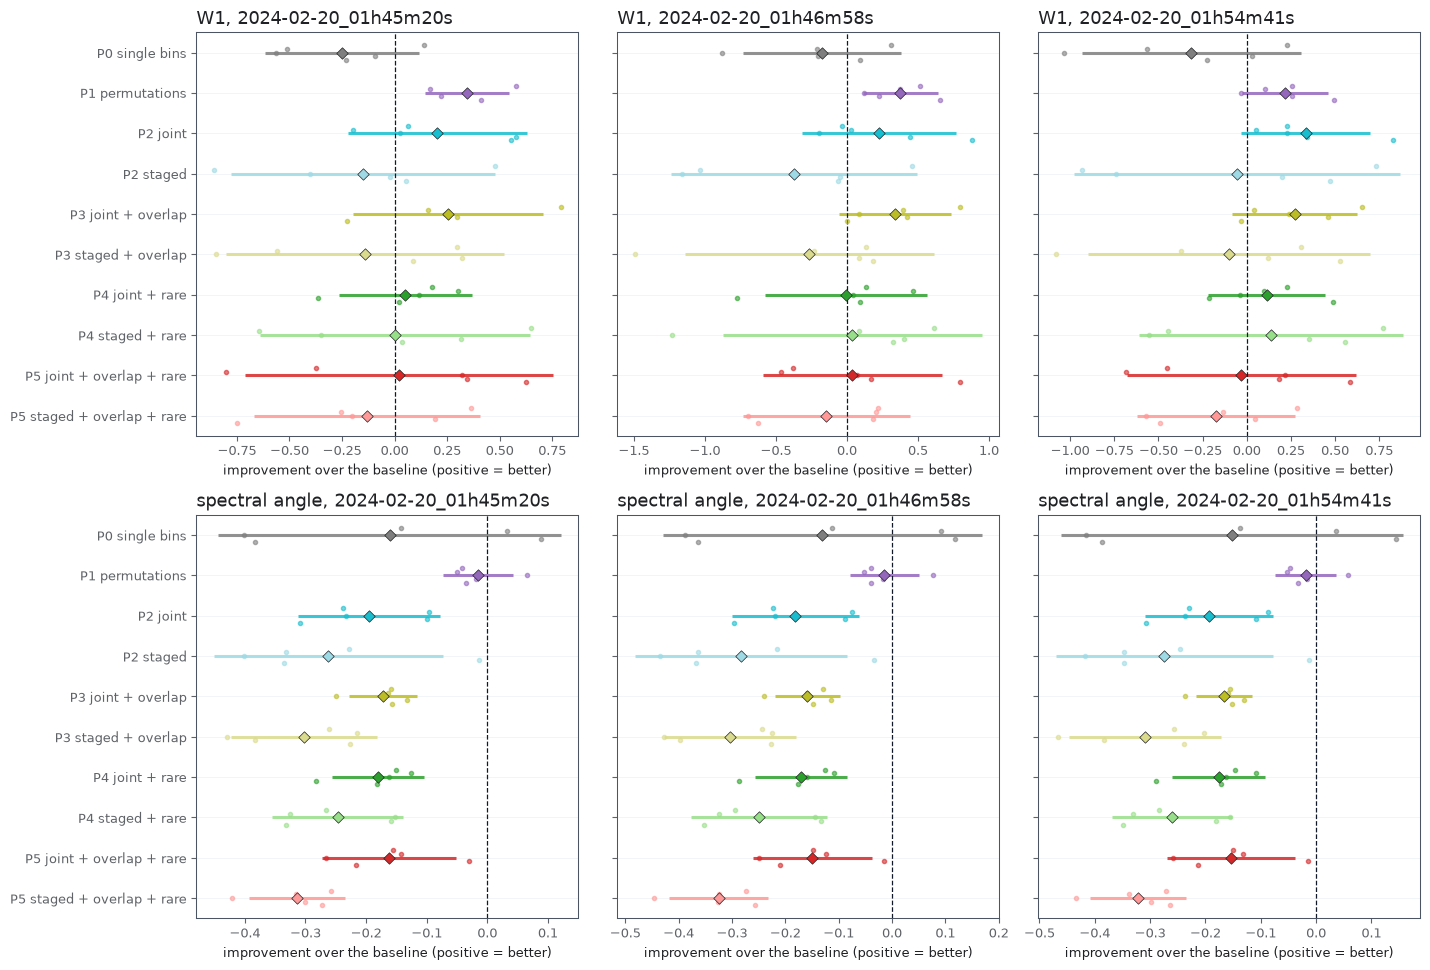

In [7]:
images = table('image_breakdown')
DATASETS = sorted(images.dataset_id.unique())
image_summary = summarize(images, ['variant', 'dataset_id', 'metric'])
panels = [(f"{SHORT[metric]}, {dataset}", {'metric': metric, 'dataset_id': dataset}) for metric in ['masserstein', 'spectral_angle'] for dataset in DATASETS]
figures.improvement_forest(image_summary, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                           paired=images, columns=3, theme=theme);

### Remarks

- W1: 2 of 30 variant x image cells improve, 0 worsen.
- spectral angle: 0 of 30 variant x image cells improve, 24 worsen.

### Notes

## Per-bin errors of the representatives

### Methodology

#### Theoretical

The mean absolute error per bin $\overline{|\hat X_j - X_j|}$ of the representative model of the baseline
and of the best variant shows which peaks the variant reconstructs better or worse.

#### Implementation

`feature_errors` (group `all`): per representative and population, per-bin means of input, output and
absolute and signed error. The representative of a cell is the repetition with the lowest mean rank of the
five key metrics on the test pixels (chosen in the `inference` level).

#### Figure descriptions

Two panels (test, held-out images); x = m/z; line = mean absolute error per bin of the baseline and of the
best variant. The table gives the summed per-bin mean absolute error (mean L1 error per spectrum) of every
variant's representative.

population,heldout_image,test
variant,,
baseline,1.3428,1.2359
P0_single,1.5836,1.6252
P1_permutation,1.2931,1.2311
P2_joint_base,1.6013,1.6379
P2_staged_base,1.4215,1.3753
P3_joint_overlap,1.6153,1.6319
P3_staged_overlap,1.6982,1.5641
P4_joint_rare,1.5888,1.6459
P4_staged_rare,1.5455,1.6292


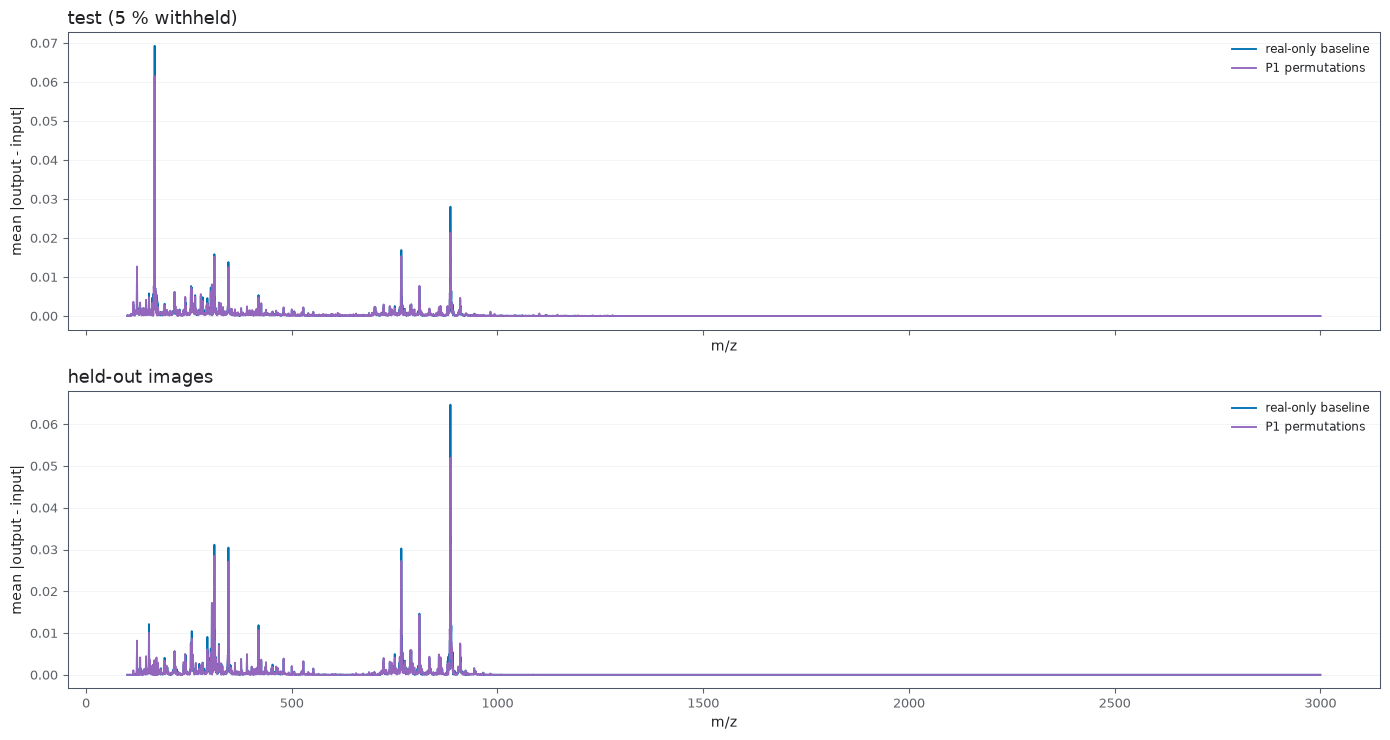

In [8]:
features = table('feature_errors')
figure, axes = plt.subplots(2, 1, figsize=(14, 7.5), dpi=theme.figure_dpi, sharex=True)
for ax, population in zip(axes, ['test', 'heldout_image']):
    rows = features[(features.population == population) & features.variant.isin([BASELINE, BEST])]
    figures.epoch_curves(rows, levels=[BASELINE, BEST], labels=VARIANT_LABELS, colors=VARIANT_COLORS, x='mz', y='mean_abs_error',
                         marker=None, xlabel='m/z', ylabel='mean |output - input|', title=EVALUATION_NAMES[population], ax=ax, theme=theme)
figure.tight_layout()
display(features.groupby(['variant', 'population']).mean_abs_error.sum().unstack().reindex(ORDER))

### Remarks

- Summed per-bin mean absolute error (test / held-out): baseline 1.24 / 1.34, best variant P1 permutations 1.23 / 1.29; range over variant representatives 1.23-1.71 (test).

### Notes

## Spectra of the baseline and the best variant

### Methodology

#### Theoretical

The same fixed test and held-out spectra (seeded choice, identical for every model) are reconstructed by
the baseline representative and by the best variant's representative.

#### Implementation

`cases`: input and reconstruction per bin of the fixed cases of both representatives.

#### Figure descriptions

First figure: full m/z range; second figure: +/- 15 m/z around the strongest input peak. Grey = input,
colours = reconstructions.

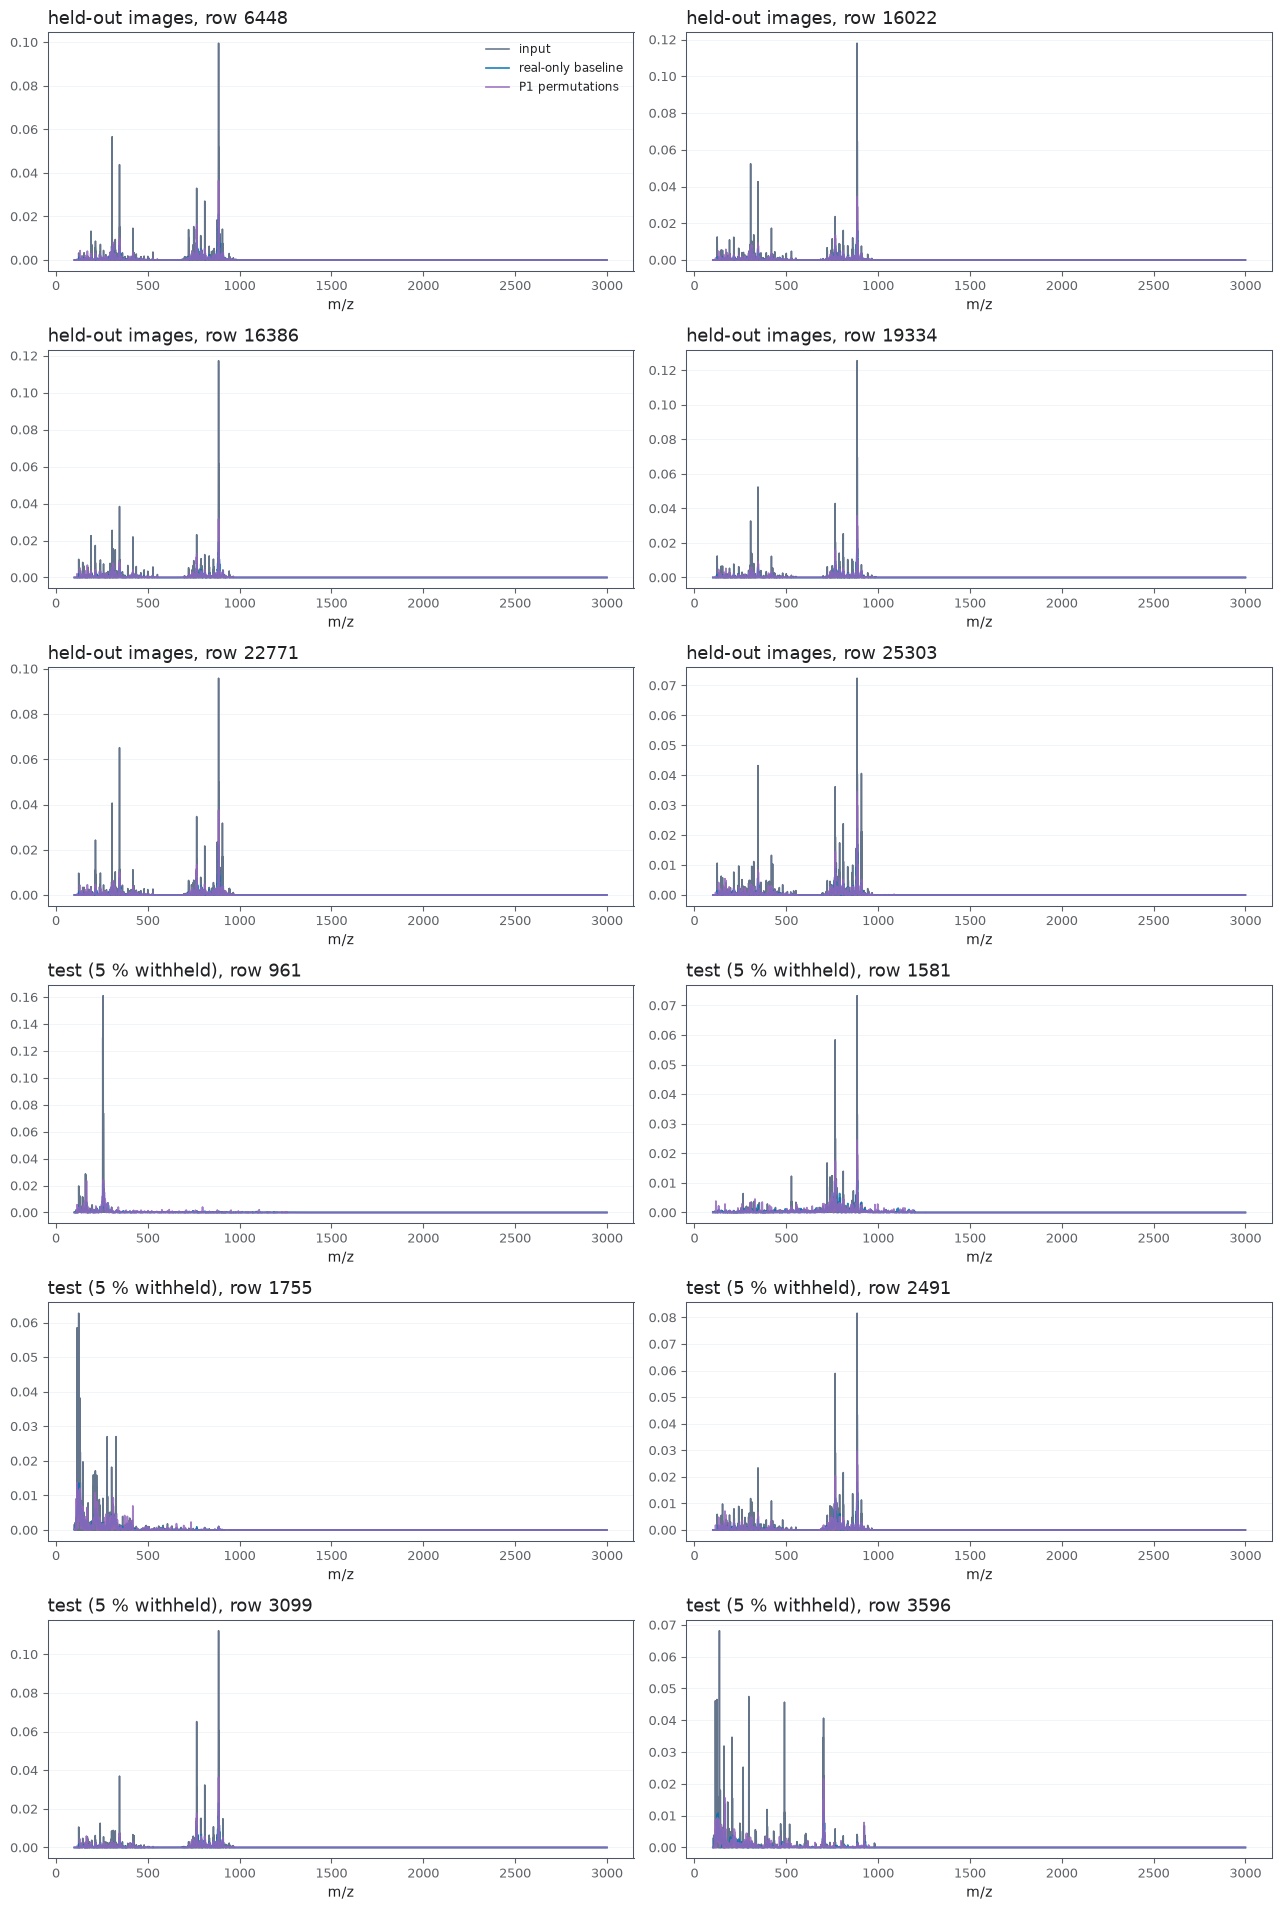

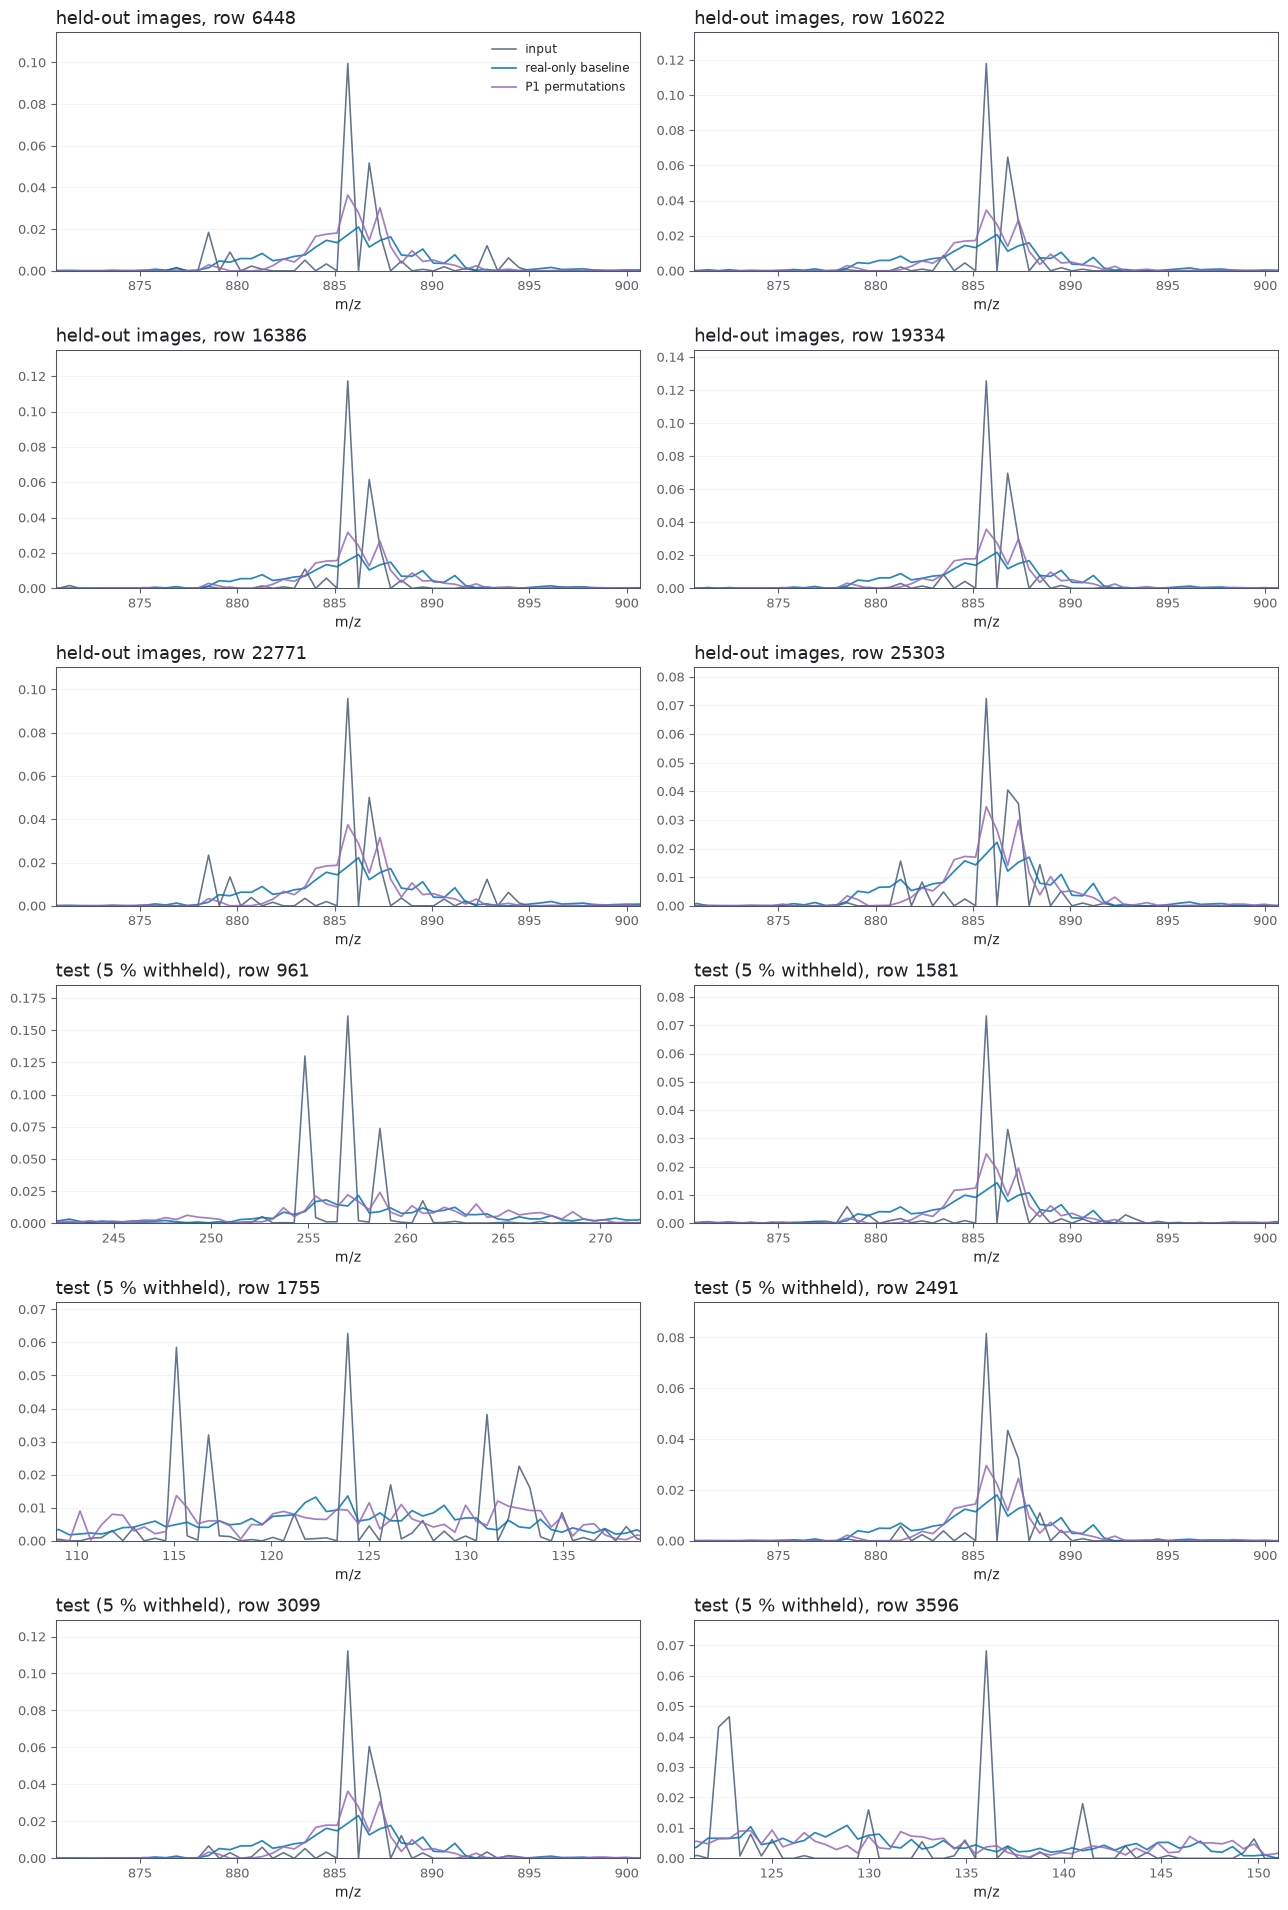

In [9]:
cases = table('cases')
keys = list(cases[['population', 'row']].drop_duplicates().sort_values(['population', 'row']).itertuples(index=False, name=None))
figures.spectrum_overlays(cases, keys=keys, levels=[BASELINE, BEST], labels=VARIANT_LABELS, colors=VARIANT_COLORS, theme=theme);
figures.spectrum_overlays(cases, keys=keys, levels=[BASELINE, BEST], labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                          zoom=settings['spectrum_zoom']['half_width'], theme=theme);

### Remarks

- Shown: baseline representative and P1 permutations (best variant of this stage).

### Notes

## Worst and best held-out spectra: the baseline against the variants on the same pixels

### Methodology

#### Theoretical

Averages do not show whether a variant repairs the spectra the baseline reconstructs worst. For the
representative models of the baseline and of every variant, held-out pixels are selected from their per-pixel
$W_1$: the two worst pixels of the baseline (the same pixels for every variant), and per variant its best and
worst pixel and the pixels with the largest paired improvement and deterioration against the baseline. The
input, the baseline reconstruction and the variant reconstruction of each pixel are drawn together, in full and
zoomed on the strongest peak and on the variant's worst window, so that the peak shape can be compared.

#### Implementation

`extreme_pixels` (selected pixels, both costs and worst windows) and `extreme_spectra` (input and both reconstructions on the stored display bins, i.e. windows with at least 1 % of the mean held-out TIC).

#### Figure descriptions

Table 1: per variant, W1 on the two baseline-worst pixels (the baseline representative in the first row, the
mean of the other four baseline repetitions in the last row: pixels chosen as the worst of one model regress
towards the mean for every other model, so a variant repairs a pixel only when it is below that row). Table 2: per
variant and pixel kind, the paired W1 change (variant - baseline; negative = the variant is better). Figure:
one pair of rows per pixel of the displayed variant (the best variant on the test pixels; change `SHOWN` to
inspect another): signal above (grey = input, black = baseline, colour = variant) and residual output - input
below; columns = full displayed range, +/- 15 m/z around the strongest input peak, the variant's
largest-contribution window. Title: kind, image, pixel and W1 baseline -> variant.

In [10]:
extreme_pixels = table('extreme_pixels')
extreme_spectra = table('extreme_spectra')
worst = extreme_pixels[extreme_pixels.pixel_kind == 'baseline_worst']
matrix = worst.pivot_table(index='variant', columns=['dataset_id', 'x', 'y'], values='masserstein')
baseline_values = worst.drop_duplicates('row').set_index(['dataset_id', 'x', 'y']).masserstein_baseline
matrix.loc[BASELINE] = baseline_values.reindex(matrix.columns).to_numpy()
others = worst.drop_duplicates('row').set_index(['dataset_id', 'x', 'y']).masserstein_baseline_others
matrix.loc['baseline, other repetitions (mean)'] = others.reindex(matrix.columns).to_numpy()
display(matrix.reindex([name for name in [*ABS_ORDER, 'baseline, other repetitions (mean)'] if name in matrix.index]).round(2))
change = extreme_pixels.assign(change=extreme_pixels.masserstein - extreme_pixels.masserstein_baseline)
display(change.pivot_table(index='variant', columns='pixel_kind', values='change', aggfunc='mean').reindex(VARIANTS).round(2))

dataset_id                         2024-02-20_01h45m20s       
x                                                    39     40
y                                                     6      5
variant                                                       
baseline                                          28.45  25.49
P0_single                                         14.11  16.31
P1_permutation                                    11.36  14.42
P2_joint_base                                     31.63  21.13
P2_staged_base                                    12.11   8.98
P3_joint_overlap                                  15.19  15.21
P3_staged_overlap                                 12.84  17.87
P4_joint_rare                                     16.06  15.12
P4_staged_rare                                    17.47  16.22
P5_joint_all                                      18.92  19.02
P5_staged_all                                     21.53  17.35
baseline, other repetitions (mean)                21.16  22.30

pixel_kind,baseline_worst,most_improved,most_worsened,variant_best,variant_worst
variant,,,,,
P0_single,-11.76,-17.65,6.18,-4.41,-4.85
P1_permutation,-14.08,-14.24,3.95,-0.62,2.01
P2_joint_base,-0.59,-8.45,5.58,-0.59,2.00
P2_staged_base,-16.43,-11.91,5.87,-0.98,-5.82
P3_joint_overlap,-11.77,-12.34,5.71,-1.58,7.46
P3_staged_overlap,-11.61,-15.99,8.47,-0.90,3.04
P4_joint_rare,-11.38,-14.55,4.90,-0.08,4.79
P4_staged_rare,-10.12,-15.63,10.10,-0.93,6.19
P5_joint_all,-8.00,-11.26,6.06,-0.60,7.71


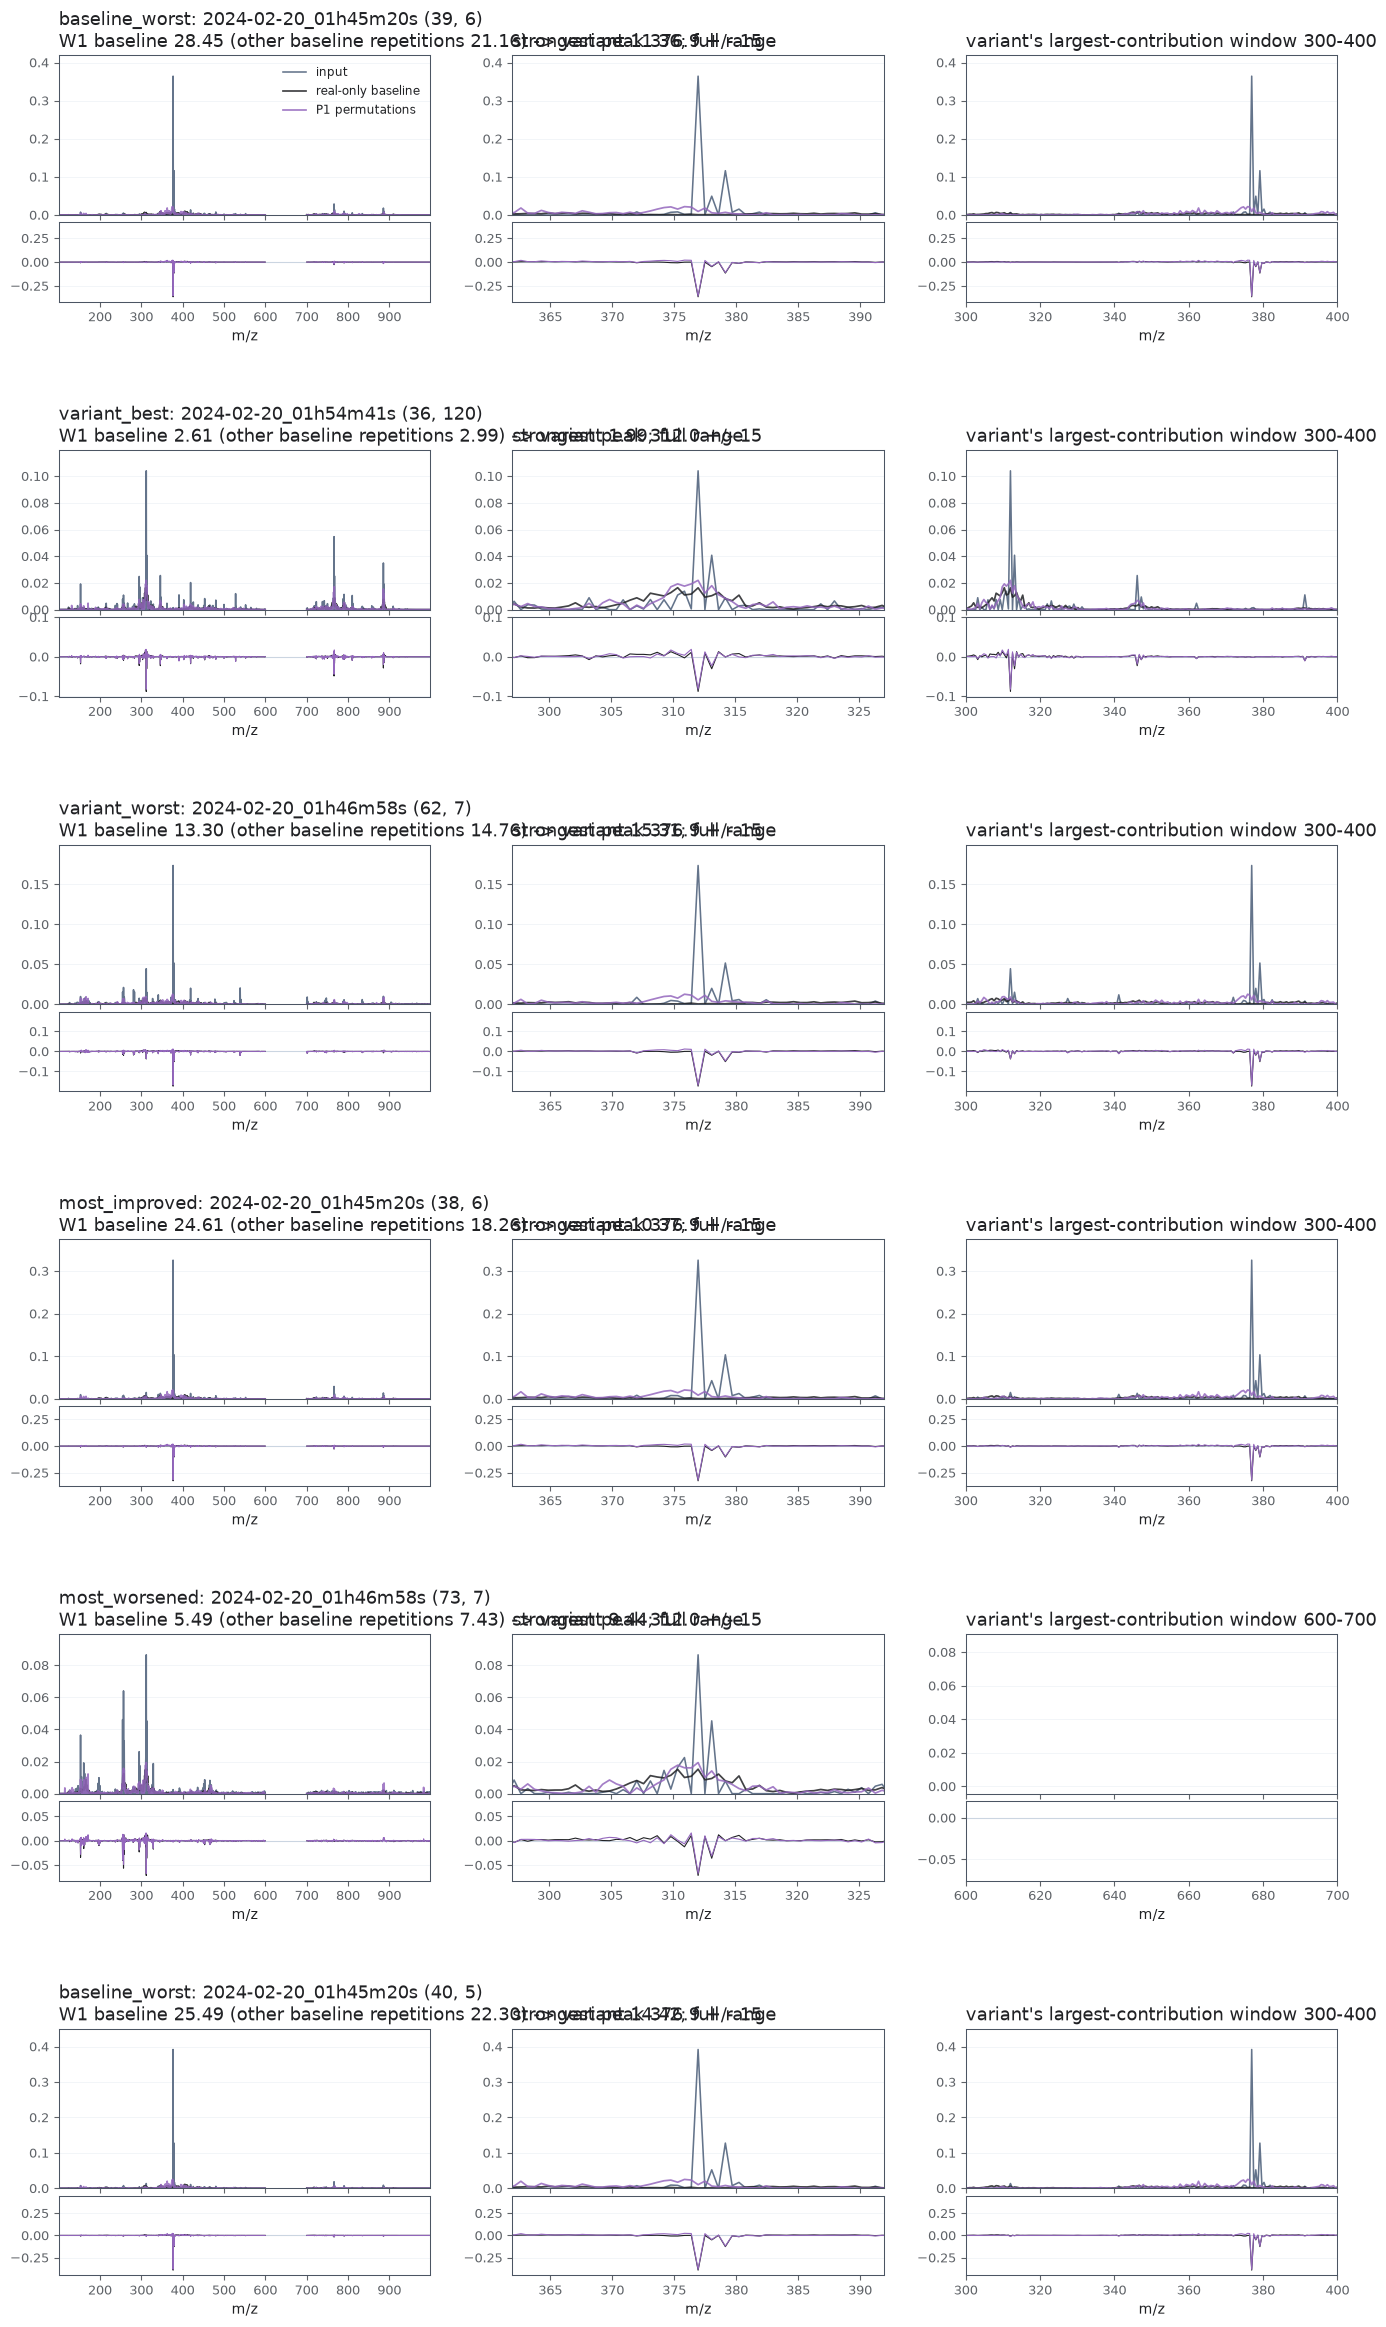

In [11]:
SHOWN = metadata['best_variant']
shown = extreme_spectra[extreme_spectra.variant == SHOWN].merge(extreme_pixels[extreme_pixels.variant == SHOWN], on=['variant', 'row'])
figures.paired_spectra(shown, variant_label=VARIANT_LABELS.get(SHOWN, SHOWN), variant_color=VARIANT_COLORS[SHOWN], theme=theme);

### Remarks

- Shown variant: P1 permutations (best on the test pixels).
- Baseline-worst pixel 2024-02-20_01h45m20s (39, 6): W1 28.45 (baseline representative; other baseline repetitions 21.16) -> 11.36 (variant); worst window 300-400 -> 300-400.
- Baseline-worst pixel 2024-02-20_01h45m20s (40, 5): W1 25.49 (baseline representative; other baseline repetitions 22.30) -> 14.42 (variant); worst window 300-400 -> 300-400.
- On the two baseline-worst pixels, 10 of 10 variants reduce the cost (mean change -10.33 W1), and 9 are also below the other baseline repetitions (21.73): pixels chosen as the worst of one model are better for almost any other model (regression to the mean), so only a cost below the other repetitions indicates a real repair.
- most improved: 2024-02-20_01h45m20s (38, 6), W1 24.61 -> 10.37.
- most worsened: 2024-02-20_01h46m58s (73, 7), W1 5.49 -> 9.44.

### Notes

## Results / Summary

### LLM

- **Observed:** held-out W1 contribution improves in 172 and worsens in 10 of 290 variant x window cells.
- **Interpretation:** on the wide axis the fine-tuned variants gain in many windows on the held-out images, i.e. the pretrained decoder places mass better on new images even where the key W1 interval is inconclusive; the spectral angle (shape of peaks) still loses (part 3_01).

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- Held-out within-window W1 per window: the baseline is beaten in 31 of 99 variant x window cells; best variant by cells: P1 permutations (5 of 10 windows).
- held-out W1 of image 2024-02-20_01h45m20s: baseline 4.572; others 4.228-4.824; 6 of 10 better than the baseline; best P1 permutations (4.228), worst P0 single bins (4.824).
- held-out W1 of image 2024-02-20_01h46m58s: baseline 4.496; others 4.119-4.866; 5 of 10 better than the baseline; best P1 permutations (4.119), worst P2 staged (4.866).
- held-out W1 of image 2024-02-20_01h54m41s: baseline 4.301; others 3.967-4.614; 5 of 10 better than the baseline; best P2 joint (3.967), worst P0 single bins (4.614).
- Shown variant: P1 permutations (best on the test pixels).
- Baseline-worst pixel 2024-02-20_01h45m20s (39, 6): W1 28.45 (baseline representative; other baseline repetitions 21.16) -> 11.36 (variant); worst window 300-400 -> 300-400.
- Baseline-worst pixel 2024-02-20_01h45m20s (40, 5): W1 25.49 (baseline representative; other baseline repetitions 22.30) -> 14.42 (variant); worst window 300-400 -> 300-400.

### Person